In [2]:
pip install pandas matplotlib openpyxl numpy

Note: you may need to restart the kernel to use updated packages.


Phase 1A: League Table and Power Rankings

Rank all 32 teams, then predict 16 matchup outcomes

In [3]:
# ============================================================
# PHASE 1a: League Table + Power Rankings
# Copy this entire cell into Jupyter and run it
# ============================================================

import pandas as pd
import numpy as np

# --- LOAD DATA ---
df = pd.read_excel('whl_2025.xlsx')

# --- STEP 1: Get one row per game (sum goals, xG) ---
games = df.groupby('game_id').agg(
    home_team=('home_team', 'first'),
    away_team=('away_team', 'first'),
    went_ot=('went_ot', 'first'),
    home_goals=('home_goals', 'sum'),
    away_goals=('away_goals', 'sum'),
    home_xg=('home_xg', 'sum'),
    away_xg=('away_xg', 'sum')
).reset_index()

# Determine winner
games['home_win'] = games['home_goals'] > games['away_goals']
games['ot_game']  = games['went_ot'] == 1

# --- STEP 2: Build points table ---
teams   = df['home_team'].unique()
records = []

for team in teams:
    home_g = games[games['home_team'] == team]
    away_g = games[games['away_team'] == team]

    hw   = home_g['home_win'].sum()
    aw   = (~away_g['home_win']).sum()
    wins = hw + aw

    h_otl   = ((~home_g['home_win']) & home_g['ot_game']).sum()
    a_otl   = (away_g['home_win'] & away_g['ot_game']).sum()
    ot_losses = h_otl + a_otl

    hl     = (~home_g['home_win']).sum()
    al     = away_g['home_win'].sum()
    losses = (hl + al) - ot_losses

    # Points: Win=2, OT Loss=1, Loss=0
    points = wins * 2 + ot_losses * 1

    n_games = len(home_g) + len(away_g)
    xgf = home_g['home_xg'].sum() + away_g['away_xg'].sum()
    xga = home_g['away_xg'].sum() + away_g['home_xg'].sum()

    records.append({
        'team': team, 'GP': n_games, 'W': wins,
        'L': losses, 'OTL': ot_losses, 'PTS': points,
        'xGF_pg': round(xgf / n_games, 3),
        'xGA_pg': round(xga / n_games, 3)
    })

league_table = pd.DataFrame(records).sort_values('PTS', ascending=False).reset_index(drop=True)

# --- STEP 3: Composite Power Score ---
def normalize(s, higher_is_better=True):
    mn, mx = s.min(), s.max()
    n = (s - mn) / (mx - mn)
    return n if higher_is_better else 1 - n

league_table['score'] = (
    normalize(league_table['PTS'])             * 0.40 +  # 40% points
    normalize(league_table['xGF_pg'])          * 0.35 +  # 35% offense
    normalize(league_table['xGA_pg'],
              higher_is_better=False)          * 0.25    # 25% defense
)

league_table['power_rank'] = league_table['score'].rank(ascending=False).astype(int)
league_table = league_table.sort_values('power_rank').reset_index(drop=True)

print('POWER RANKINGS (submit this order):')
print(league_table[['power_rank','team','PTS','xGF_pg','xGA_pg']].to_string())
league_table.to_csv('power_rankings.csv', index=False)



POWER RANKINGS (submit this order):
    power_rank          team  PTS  xGF_pg  xGA_pg
0            1        brazil  122   3.323   2.705
1            2      thailand  107   3.594   2.703
2            3      pakistan  106   3.472   2.847
3            4   netherlands  114   2.957   2.461
4            5          peru  112   2.982   2.621
5            6         china  101   3.121   2.695
6            7        panama  101   3.140   2.944
7            8            uk   91   3.370   2.927
8            9         india  104   2.919   2.902
9           10        mexico   87   3.219   2.717
10          11     guatemala   92   3.118   2.839
11          12        france   85   3.252   2.855
12          13        serbia   88   3.382   3.222
13          14       iceland  101   2.806   3.033
14          15   south_korea   86   3.169   3.063
15          16      ethiopia   98   2.920   3.204
16          17   philippines   99   2.605   2.880
17          18       morocco   85   3.043   2.971
18          19

Phase 1A: Win Probabilities

In [4]:
# ============================================================
# PHASE 1a: Win Probabilities for 16 Matchups
# Run AFTER the league table code above
# ============================================================

matchups = pd.read_excel('WHSDSC_Rnd1_matchups.xlsx')

score_lookup = league_table.set_index('team')['score'].to_dict()

# Home advantage: observed home win rate is 56.4%, so add ~6%
HOME_ADV = 0.06

results = []
for _, row in matchups.iterrows():
    h, a  = row['home_team'], row['away_team']
    hs    = score_lookup.get(h, 0.5)
    a_s   = score_lookup.get(a, 0.5)

    base_prob     = hs / (hs + a_s)
    home_win_prob = round(min(max(base_prob + HOME_ADV, 0.05), 0.95), 3)

    results.append({
        'game':             row['game'],
        'home_team':        h,
        'away_team':        a,
        'home_win_prob':    home_win_prob
    })

win_probs = pd.DataFrame(results)
print('WIN PROBABILITIES (submit these 16 values):')
print(win_probs.to_string())
win_probs.to_csv('win_probabilities.csv', index=False)


WIN PROBABILITIES (submit these 16 values):
    game    home_team     away_team  home_win_prob
0      1       brazil    kazakhstan          0.840
1      2  netherlands      mongolia          0.950
2      3         peru        rwanda          0.810
3      4     thailand          oman          0.786
4      5     pakistan       germany          0.734
5      6        india           usa          0.696
6      7       panama   switzerland          0.719
7      8      iceland        canada          0.587
8      9        china        france          0.606
9     10  philippines       morocco          0.561
10    11     ethiopia  saudi_arabia          0.604
11    12    singapore   new_zealand          0.533
12    13    guatemala   south_korea          0.595
13    14           uk        mexico          0.570
14    15      vietnam        serbia          0.464
15    16    indonesia           uae          0.584


PHASE 1a DELIVERABLES READY  Submit: (1) The ranked list of all 32 teams from power_rankings.csv — use the power_rank column. (2) The 16 home_win_prob values from win_probabilities.csv. All numbers should be decimals between 0 and 1 (e.g., 0.62 not 62%).

Phase 1B: Offensive Line Quality Disparity

Rank the top 10 teams by how much their 1st line outperforms their 2nd


In [6]:
# ============================================================
# PHASE 1b: Offensive Line Disparity
# Run in a new cell — needs df loaded from Phase 1a
# ============================================================

# Filter to only regular offensive line matchups
off_rows = df[df['home_off_line'].isin(['first_off', 'second_off'])].copy()

# xG per minute of TOI (TOI is in seconds, divide by 60)
off_rows['home_xg_per_min'] = off_rows['home_xg'] / (off_rows['toi'] / 60)
off_rows['away_xg_per_min'] = off_rows['away_xg'] / (off_rows['toi'] / 60)

# Average xG/min for each team's line (home perspective)
home_lines = off_rows.groupby(['home_team', 'home_off_line'])['home_xg_per_min'].mean().reset_index()
home_lines.columns = ['team', 'line', 'xg_per_min']

# Same for away teams
away_lines = off_rows.groupby(['away_team', 'away_off_line'])['away_xg_per_min'].mean().reset_index()
away_lines.columns = ['team', 'line', 'xg_per_min']

# Combine and average home + away for each line
all_lines = pd.concat([home_lines, away_lines])
avg_lines = all_lines.groupby(['team', 'line'])['xg_per_min'].mean().unstack()
avg_lines.columns.name = None
avg_lines = avg_lines.reset_index()

# Only keep first_off and second_off columns if they exist
expected_lines = ['first_off', 'second_off']
existing_lines = [col for col in expected_lines if col in avg_lines.columns]
avg_lines = avg_lines[['team'] + existing_lines]
avg_lines.columns = ['team'] + [f'{line}_xg' for line in existing_lines]

# Disparity ratio: first line / second line
if 'first_off_xg' in avg_lines.columns and 'second_off_xg' in avg_lines.columns:
    avg_lines['disparity_ratio'] = avg_lines['first_off_xg'] / avg_lines['second_off_xg']
else:
    avg_lines['disparity_ratio'] = float('nan')  # or handle as needed

avg_lines = avg_lines.sort_values('disparity_ratio', ascending=False).reset_index(drop=True)
avg_lines['disparity_rank'] = avg_lines.index + 1

print('TOP 10 LINE DISPARITY (submit ranks 1-10):')
print(avg_lines.head(10)[['disparity_rank','team','disparity_ratio',
                          'first_off_xg','second_off_xg']])
avg_lines.to_csv('line_disparity.csv', index=False)


TOP 10 LINE DISPARITY (submit ranks 1-10):
   disparity_rank          team  disparity_ratio  first_off_xg  second_off_xg
0               1     guatemala         1.472265      0.047431       0.032216
1               2           usa         1.426697      0.044832       0.031423
2               3           uae         1.424390      0.032841       0.023056
3               4  saudi_arabia         1.398297      0.035919       0.025688
4               5       iceland         1.378072      0.043856       0.031824
5               6        france         1.353371      0.041085       0.030357
6               7     singapore         1.271183      0.043452       0.034182
7               8   new_zealand         1.252480      0.039337       0.031408
8               9        panama         1.242106      0.043485       0.035009
9              10          peru         1.233525      0.039542       0.032056


PHASE 1b DELIVERABLE READY  Submit: The top 10 teams from line_disparity.csv, ranked 1 through 10 by disparity_rank. Copy the team names in order.


Phase 1C: Data Visualization

A scatter plot showing whether line balance predicts team success


Chart saved as BrooklineFintechFishes.png


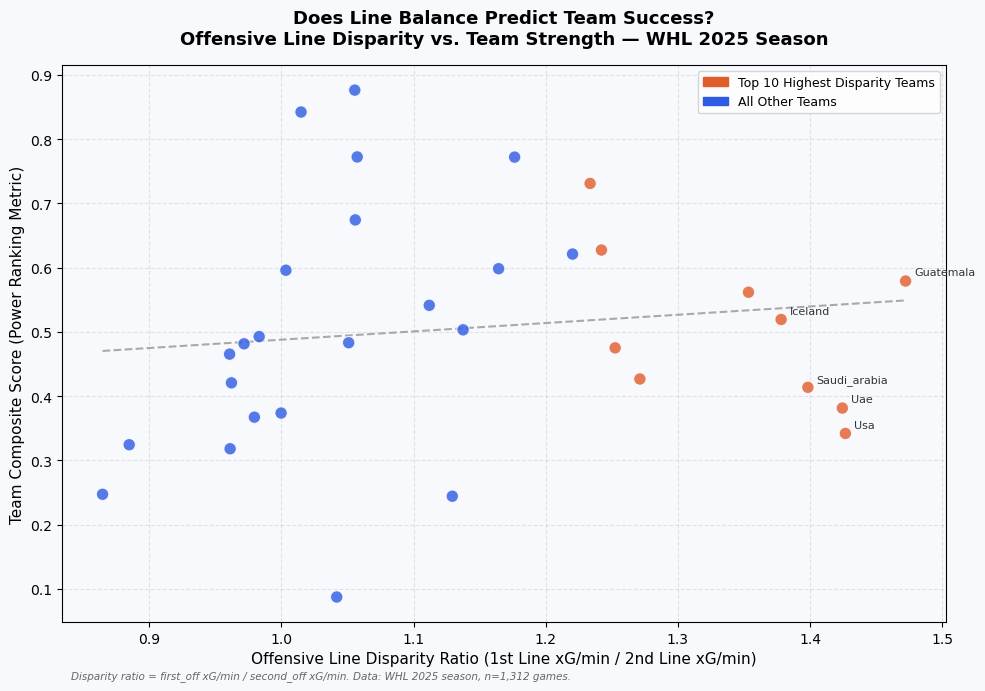

In [7]:
# ============================================================
# PHASE 1c: Visualization — saves YourTeamName.png
# IMPORTANT: Change TEAM_NAME below before running!
# Needs avg_lines (from 1b) and league_table (from 1a)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

TEAM_NAME = 'BrooklineFintechFishes'   # <-- CHANGE THIS (no spaces)

# Merge power score with disparity ratio
viz_data = avg_lines.merge(league_table[['team', 'score', 'PTS']], on='team')

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#f7f9fc')
ax.set_facecolor('#f7f9fc')

# Color top-10 disparity teams differently
top10_teams = avg_lines.head(10)['team'].values
colors = ['#e05c2b' if t in top10_teams else '#2d5be3'
          for t in viz_data['team']]

ax.scatter(viz_data['disparity_ratio'], viz_data['score'],
           c=colors, s=80, alpha=0.8,
           edgecolors='white', linewidth=0.8, zorder=3)

# Trendline
z = np.polyfit(viz_data['disparity_ratio'], viz_data['score'], 1)
p = np.poly1d(z)
x_line = np.linspace(viz_data['disparity_ratio'].min(),
                     viz_data['disparity_ratio'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#888',
        linewidth=1.5, alpha=0.7, label='Trend')

# Label top 5 highest-disparity teams
top5 = avg_lines.head(5)['team'].values
for _, row in viz_data.iterrows():
    if row['team'] in top5:
        ax.annotate(row['team'].capitalize(),
                    (row['disparity_ratio'], row['score']),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=8, color='#333')

# Formatting
ax.set_xlabel('Offensive Line Disparity Ratio (1st Line xG/min / 2nd Line xG/min)',
              fontsize=11)
ax.set_ylabel('Team Composite Score (Power Ranking Metric)', fontsize=11)
ax.set_title('Does Line Balance Predict Team Success?\n'
             'Offensive Line Disparity vs. Team Strength — WHL 2025 Season',
             fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--')

legend_handles = [
    mpatches.Patch(color='#e05c2b', label='Top 10 Highest Disparity Teams'),
    mpatches.Patch(color='#2d5be3', label='All Other Teams'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='upper right')

ax.text(0.01, -0.10,
    'Disparity ratio = first_off xG/min / second_off xG/min. '
    'Data: WHL 2025 season, n=1,312 games.',
    transform=ax.transAxes, fontsize=7.5,
    color='#666', style='italic')

plt.tight_layout()
filename = f'{TEAM_NAME}.png'
plt.savefig(filename, dpi=150, bbox_inches='tight',
            facecolor='#f7f9fc')
print(f'Chart saved as {filename}')
plt.show()


Phase 1D — Tell Your Story (Methodology Write-up)

**PROCESS**


Data cleaning/transformation (~50 words):


Additional variables created (~25 words):


**TOOLS AND TECHNIQUES**


Software tools used:


How tools were used (~50 words):


Statistical methods (~100 words):


**OUR PREDICTIONS**

1a — Power rankings and win probabilities (~50 words):


1b — Offensive line quality disparity (~50 words):


1c — Visualization choices (~50 words):


**OUR INSIGHTS**


Model performance assessment (~50 words):


Generative AI usage (~50 words):